In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def sir_two_populations(t, y, b1, b2, gamma1, gamma2, h):
    S1, I1, R1, S2, I2, R2 = y

    exp_h = np.exp(-h)
    interaction_factor = 2 / (1 + exp_h)

    
    dS1 = -b1 * (I1 + exp_h * I2) * interaction_factor * S1
    dI1 = b1 * (I1 + exp_h * I2) * interaction_factor * S1 - gamma1 * I1
    dR1 = gamma1 * I1
    
    dS2 = -b2 * (I2 + exp_h * I1) * interaction_factor * S2
    dI2 = b2 * (I2 + exp_h * I1) * interaction_factor * S2 - gamma2 * I2
    dR2 = gamma2 * I2
    
    return [dS1, dI1, dR1, dS2, dI2, dR2]

def get_r_inf(h, b1, b2, gamma1, gamma2, y0, t_max):
    solution = solve_ivp(
        sir_two_populations, 
        (0, t_max), 
        y0, 
        args=(b1, b2, gamma1, gamma2, h),
        method='RK45',
        dense_output=False
    )
    
    final_state = solution.y[:, -1]
    r_inf_1 = final_state[2] + final_state[1]  # R1 + I1
    r_inf_2 = final_state[5] + final_state[4]  # R2 + I2
    
    return r_inf_1, r_inf_2, solution.y

# Parameters
b1 = 0.2
b2 = b1*0.2
gamma1 = 0.1
gamma2 = 0.1
I0 = 1e-4
y0 = np.array([1-I0,I0,0,1-I0,I0,0])/2
t_max = 500

# Sweep h values
h_values = np.linspace(0, 6, 100)
r_inf_1_values = []
r_inf_2_values = []

for h in h_values:
    r_inf_1, r_inf_2, sol = get_r_inf(h, b1, b2, gamma1, gamma2, y0, t_max)
    r_inf_1_values.append(r_inf_1)
    r_inf_2_values.append(r_inf_2)

r_inf_1_values = np.array(r_inf_1_values)
r_inf_2_values = np.array(r_inf_2_values)

Text(0.5, 1.0, 'beta = 0.4')

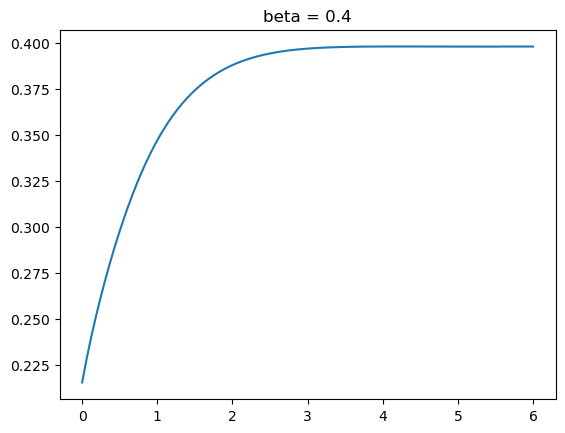

In [2]:
plt.plot(h_values,r_inf_1_values+r_inf_2_values)
plt.title("beta = 0.4")

In [3]:
import numpy as np
from scipy.integrate import solve_ivp

def sweep_h_two_populations(b1, b2, gamma1=0.1, gamma2=0.1, I0=1e-4, 
                           h_min=0, h_max=6, n_h=100, t_max=500):
    """
    Sweep homophily parameter h for two-population SIR model
    
    Args:
        b1: transmission rate for population 1
        b2: transmission rate for population 2
        gamma1: recovery rate for population 1
        gamma2: recovery rate for population 2
        I0: initial infected proportion
        h_min: minimum h value
        h_max: maximum h value
        n_h: number of h values to test
        t_max: simulation time
        
    Returns:
        h_values: array of h values
        r_inf_1: final R+I for population 1
        r_inf_2: final R+I for population 2
    """
    def sir_two_populations(t, y, b1, b2, gamma1, gamma2, h):
        S1, I1, R1, S2, I2, R2 = y
        exp_h = np.exp(-h)
        interaction_factor = 2 / (1 + exp_h)
        
        dS1 = -b1 * (I1 + exp_h * I2) * interaction_factor * S1
        dI1 = b1 * (I1 + exp_h * I2) * interaction_factor * S1 - gamma1 * I1
        dR1 = gamma1 * I1
        
        dS2 = -b2 * (I2 + exp_h * I1) * interaction_factor * S2
        dI2 = b2 * (I2 + exp_h * I1) * interaction_factor * S2 - gamma2 * I2
        dR2 = gamma2 * I2
        
        return [dS1, dI1, dR1, dS2, dI2, dR2]
    
    y0 = np.array([1-I0, I0, 0, 1-I0, I0, 0]) / 2
    h_values = np.linspace(h_min, h_max, n_h)
    
    r_inf_1 = np.zeros(n_h)
    r_inf_2 = np.zeros(n_h)
    
    for i, h in enumerate(h_values):
        sol = solve_ivp(
            sir_two_populations, 
            (0, t_max), 
            y0, 
            args=(b1, b2, gamma1, gamma2, h),
            method='RK45'
        )
        final = sol.y[:, -1]
        r_inf_1[i] = final[2] + final[1]  # R1 + I1
        r_inf_2[i] = final[5] + final[4]  # R2 + I2
    


    return h_values, r_inf_1, r_inf_2

In [4]:
beta_Ms = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55]
n_h = 100
RES = np.zeros((len(beta_Ms), n_h))

for indx, beta in enumerate(beta_Ms):
    h_values, r_inf_1, r_inf_2 = sweep_h_two_populations(b1=beta, b2=beta*0.2, n_h = n_h)
    r_tot = r_inf_1 + r_inf_2
    RES[indx,:] = r_tot


1.5 0.3
2.0 0.4
2.5 0.5
3.0 0.6
3.5 0.7
4.0 0.8
4.5 0.9
5.0 1.0
5.5 1.1


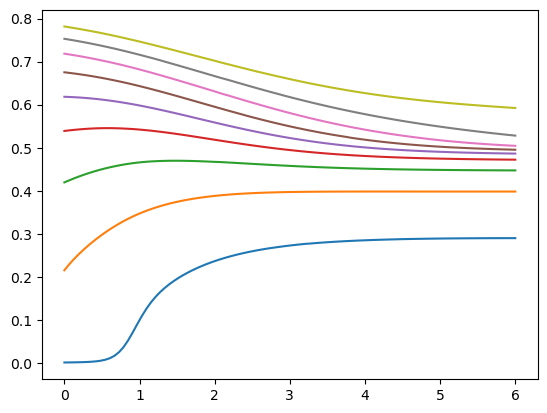

In [5]:
fig, ax = plt.subplots(1,1)

for i in range(len(beta_Ms)):
    ax.plot(h_values,RES[i,:])
    print(np.round(beta_Ms[i]/0.1,1), np.round(beta_Ms[i]*0.2/0.1,1))

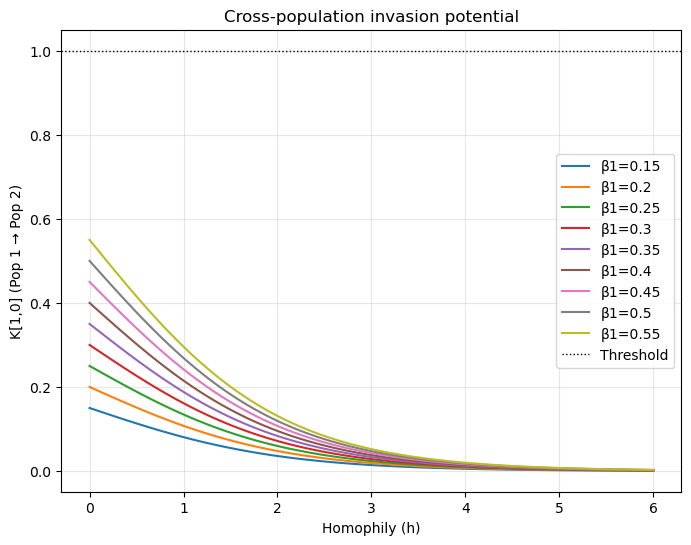

In [9]:
def calculate_K_10(b1, b2, gamma1, gamma2, h, N1=0.5, N2=0.5):
    """
    Calculate K[1,0]: secondary infections in population 2 from one infected in population 1
    
    Args:
        b1: transmission rate for population 1
        b2: transmission rate for population 2
        gamma1: recovery rate for population 1
        gamma2: recovery rate for population 2
        h: homophily parameter
        N1, N2: population sizes
    
    Returns:
        K_10: secondary infections in pop 2 from one infected in pop 1
    """
    exp_h = np.exp(-h)
    interaction_factor = 2 / (1 + exp_h)
    
    K_10 = (b2 / gamma2) * exp_h * interaction_factor * N2
    
    return K_10


def sweep_K_10_vs_h(b1, b2, gamma1=0.1, gamma2=0.1, h_min=0, h_max=6, n_h=100):
    """
    Calculate K[1,0] across h sweep
    """
    h_values = np.linspace(h_min, h_max, n_h)
    K_10_values = np.zeros(n_h)
    
    for i, h in enumerate(h_values):
        K_10_values[i] = calculate_K_10(b1, b2, gamma1, gamma2, h)
    
    return h_values, K_10_values


# Create the plot matching your format
beta_Ms = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55]
n_h = 100

RES_K_10 = np.zeros((len(beta_Ms), n_h))

for indx, beta in enumerate(beta_Ms):
    h_values, K_10 = sweep_K_10_vs_h(b1=beta, b2=beta*0.2, n_h=n_h)
    RES_K_10[indx, :] = K_10

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

for i in range(len(beta_Ms)):
    ax.plot(h_values, RES_K_10[i, :], label=f'β1={beta_Ms[i]}')

ax.axhline(y=1, color='k', linestyle=':', linewidth=1, label='Threshold')
ax.set_xlabel('Homophily (h)')
ax.set_ylabel('K[1,0] (Pop 1 → Pop 2)')
ax.set_title('Cross-population invasion potential')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

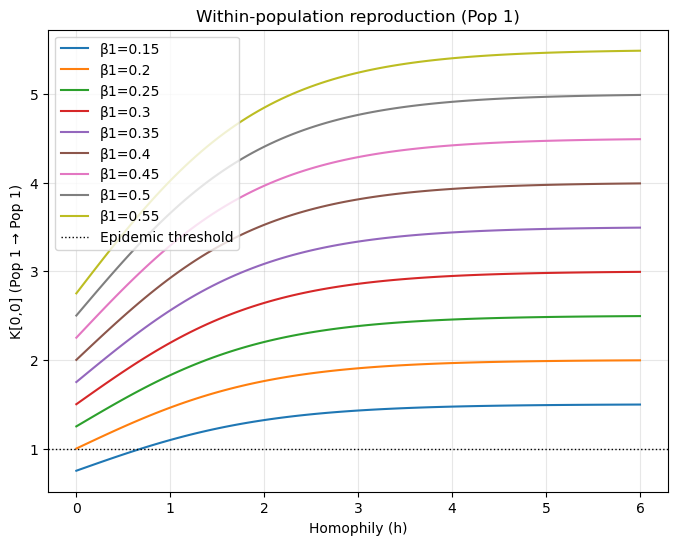

In [10]:
def calculate_K_00(b1, b2, gamma1, gamma2, h, N1=0.5, N2=0.5):
    """
    Calculate K[0,0]: secondary infections in population 1 from one infected in population 1
    """
    exp_h = np.exp(-h)
    interaction_factor = 2 / (1 + exp_h)
    
    K_00 = (b1 / gamma1) * interaction_factor * N1
    
    return K_00


def sweep_K_00_vs_h(b1, b2, gamma1=0.1, gamma2=0.1, h_min=0, h_max=6, n_h=100):
    """
    Calculate K[0,0] across h sweep
    """
    h_values = np.linspace(h_min, h_max, n_h)
    K_00_values = np.zeros(n_h)
    
    for i, h in enumerate(h_values):
        K_00_values[i] = calculate_K_00(b1, b2, gamma1, gamma2, h)
    
    return h_values, K_00_values


# Plot K[0,0] for all betas
beta_Ms = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55]
n_h = 100

RES_K_00 = np.zeros((len(beta_Ms), n_h))

for indx, beta in enumerate(beta_Ms):
    h_values, K_00 = sweep_K_00_vs_h(b1=beta, b2=beta*0.2, n_h=n_h)
    RES_K_00[indx, :] = K_00

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

for i in range(len(beta_Ms)):
    ax.plot(h_values, RES_K_00[i, :], label=f'β1={beta_Ms[i]}')

ax.axhline(y=1, color='k', linestyle=':', linewidth=1, label='Epidemic threshold')
ax.set_xlabel('Homophily (h)')
ax.set_ylabel('K[0,0] (Pop 1 → Pop 1)')
ax.set_title('Within-population reproduction (Pop 1)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()